In [31]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve()))

import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast

from preprocessing import load_raw

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

df = load_raw()
df["year"] = pd.to_datetime(df["release_date"], errors="coerce").dt.year

def _extract_tokens(value):
    """"['A', \"B's\"]" -> ['A', "B's"]"""
    if pd.isna(value):
        return []
    try:
        result = ast.literal_eval(str(value))
        return result if isinstance(result, list) else []
    except (ValueError, SyntaxError):
        return []

print(f"Kształt: {df.shape}")
df.head(3)

Wczytano 63,249 wierszy, 23 kolumn z final_dataset.parquet
Kształt: (63249, 24)


,id,title,duration,mpa,rating,votes,méta_score,description,movie_link,writers,...,gross_worldwide,gross_us_canada,release_date,countries_origin,filming_locations,production_companies,awards_content,genres,languages,year
0,tt0027483,The Crimson Circle,1h 16m,NaN,6.4,30,NaN,An extortion ring murders anyone who refuses t...,https://www.imdb.com/title/tt0027483/,"['Reginald Denham', 'Edgar Wallace', 'Howard I...",...,NaN,NaN,1936-08-10,['United Kingdom'],NaN,['Richard Wainwright Productions'],NaN,['Drama'],['English'],1936
1,tt0058131,The Mystery of Thug Island,1h 36m,NaN,5.0,114,NaN,"Three year old Ada, daughter of the British ca...",https://www.imdb.com/title/tt0058131/,"['Emilio Salgari', 'Arpad DeRiso', 'Ottavio Po...",...,NaN,NaN,1966-05-28,"['Italy', 'Monaco', 'West Germany']",NaN,"['Eichberg-Film', 'Liber Film']",NaN,['Adventure'],['Italian'],1966
2,tt0042760,Las mujeres de mi general,1h 52m,Not Rated,6.8,74,NaN,Infante stars as a rebel general caught up in ...,https://www.imdb.com/title/tt0042760/,"['Joselito Rodríguez', 'Celestino Gorostiza', ...",...,NaN,NaN,1951-07-13,['Mexico'],NaN,['Producciones Rodríguez Hermanos'],NaN,"['Drama', 'War']",['Spanish'],1951


In [32]:
key_cols = ["title", "year", "rating", "genres", "directors", "stars", "description"]
missing_pct = (df[key_cols].isnull().sum() / len(df) * 100).round(1).sort_values(ascending=False)
print(missing_pct.to_string())

rating         6.4
description    3.7
genres         1.2
stars          0.5
directors      0.1
year           0.0
title          0.0


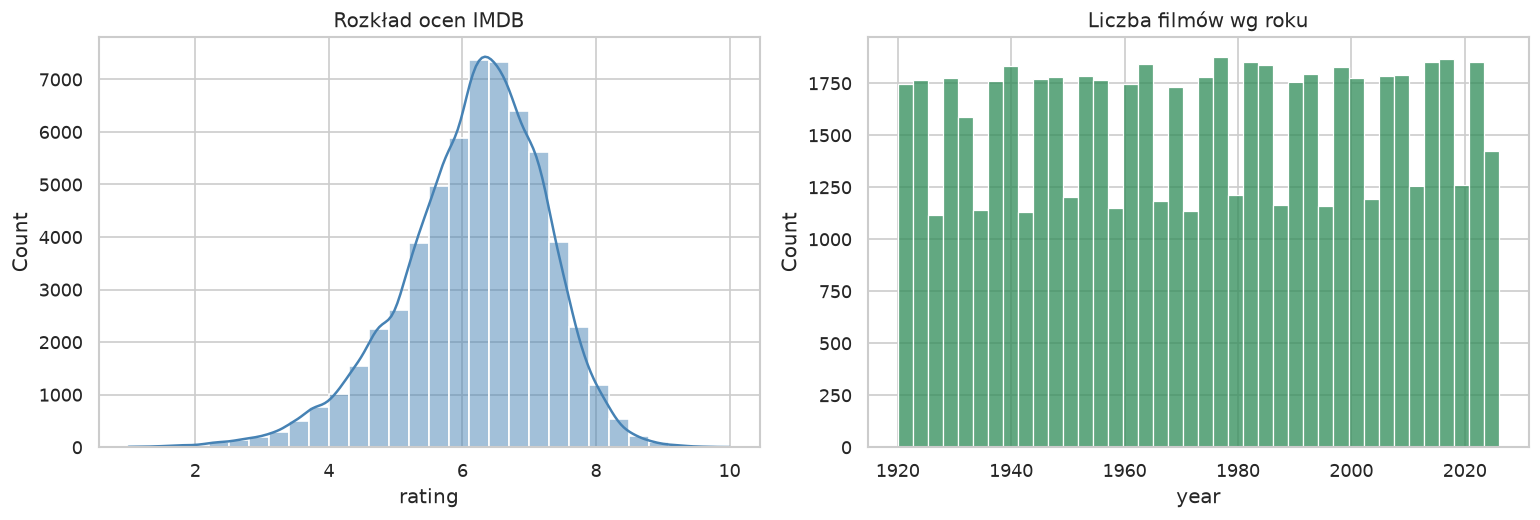

count    59181.00
mean         6.16
std          1.07
min          1.00
25%          5.50
50%          6.30
75%          6.90
max         10.00
Name: rating, dtype: float64


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["rating"].dropna(), bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Rozkład ocen IMDB")

sns.histplot(df["year"].dropna(), bins=40, ax=axes[1], color="seagreen")
axes[1].set_title("Liczba filmów wg roku")
plt.tight_layout()
plt.show()

print(df["rating"].describe().round(2))

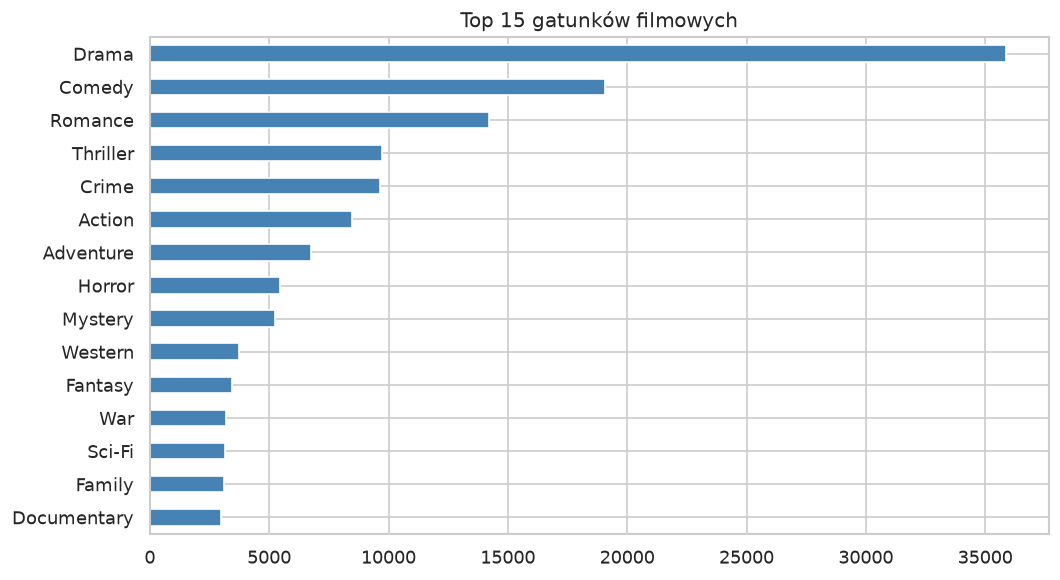

In [34]:
genre_counter = Counter([g for genres in df["genres"].apply(_extract_tokens) for g in genres])
top_genres = pd.Series(genre_counter).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
top_genres.plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Top 15 gatunków filmowych")
plt.tight_layout()
plt.show()

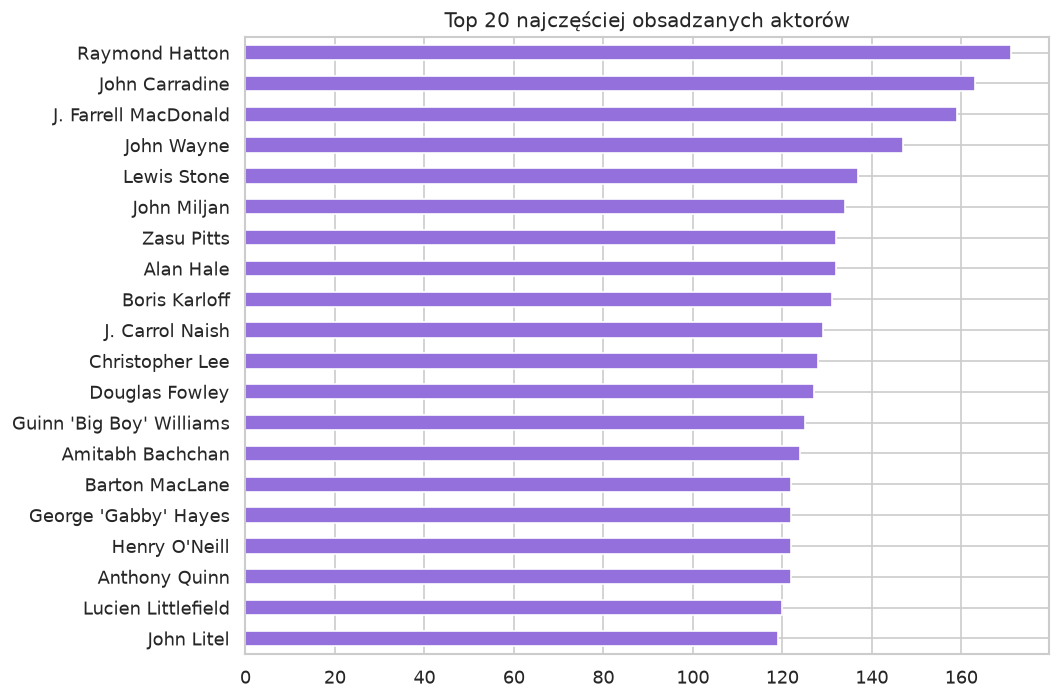

In [35]:
star_counter = Counter([s for stars in df["stars"].apply(_extract_tokens) for s in stars])
top_stars = pd.Series(star_counter).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top_stars.plot(kind="barh", ax=ax, color="mediumpurple")
ax.invert_yaxis()
ax.set_title("Top 20 najczęściej obsadzanych aktorów")
plt.tight_layout()
plt.show()

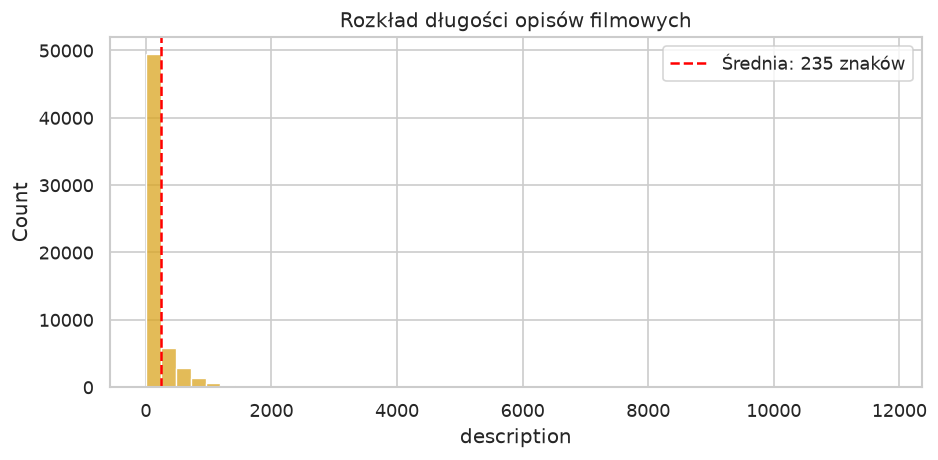

In [36]:
desc_lengths = df["description"].dropna().str.len()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(desc_lengths, bins=50, ax=ax, color="goldenrod")
ax.axvline(desc_lengths.mean(), color="red", linestyle="--",
           label=f"Średnia: {desc_lengths.mean():.0f} znaków")
ax.set_title("Rozkład długości opisów filmowych")
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
# Liczba niepustych wartości w kluczowych kolumnach
for col in ["genres", "directors", "stars", "description"]:
    non_null = df[col].notna().sum()
    print(f"  {col}: {non_null:,} ({non_null/len(df)*100:.1f}%)")

  genres: 62,462 (98.8%)
  directors: 63,198 (99.9%)
  stars: 62,905 (99.5%)
  description: 60,889 (96.3%)
